In [1]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import matthews_corrcoef, confusion_matrix, accuracy_score

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
import matplotlib.pyplot as plt
import pandas as pd
import model as m
import seaborn as sns
import divide_bins as divide
import numpy as np
import regression as reg


2024-06-13 16:50:06.723432: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-06-13 16:50:06.725499: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-13 16:50:06.751624: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-13 16:50:06.751655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-13 16:50:06.752365: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
file_name = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/outputs/micro_2_Combat_smote_8_classes.csv"
df = pd.read_csv(file_name)
df.columns

Index(['U48705', 'M87338', 'X51757', 'X69699', 'L36861', 'L13852', 'X55005',
       'X79510', 'M21121', 'J02843',
       ...
       'AI654857', 'W22117', 'AI028241', 'AI571298', 'AA149545', 'C18318',
       'AI219073', 'AI205180', 'AI363375', 'Age'],
      dtype='object', length=51277)

In [2]:
root = "/home/karen/Documents/phd/Data/Batch_corrected"

files = [
    #"micro_z_Combat.csv",
    #"RNAs_2_reCombat.csv",
    #"micro_2_Combat.csv",
    #"micro_z_reCombat.csv",
    #"RNAs_z_Combat.csv",
    #"micro_2_reCombat.csv",
    #"RNAs_2_Combat.csv",
    "RNAs_z_Combat_2.csv",
    #"RNAs_z_reCombat.csv"
]


In [9]:
def eval_regression_file(f, method="L2"):
    assert method in ["L1", "L2"]
    eval={"File": f}
    if "micro" in f:
        eval["Technology"]="Microarray"
    else:
        eval["Technology"]= "RNAseq"
    
    if "z" in f:
        eval["Normalization"]= "Z-score"
    else:
        eval["Normalization"]="Two-step"
    
    if "reCombat" in f:
        eval["BatchCorrection"]= "reCombat"
    else:
        eval["BatchCorrection"]="Combat"
        
    dataset = pd.read_csv(f"{root}/{f}")
    section_df = dataset.drop(columns=["Age"])
    section_df_age = dataset["Age"]
    section_df = m.remove_non_numeric_columns(section_df)
    if method == "L2":
        result_df, result_metrics, _ = reg.ridge_L2(X=section_df, y=section_df_age, z=dataset["Experiment"], test_size=0.4)
    elif method == "L1":
        result_df, result_metrics, _ = reg.lasso_L1(X=section_df, y=section_df_age, z=dataset["Experiment"])
    age_ranges = divide.get_age_distribution(result_df["Actual"], age_ranges=[18, 25, 35, 45,50,55,60,70, 100])
    y_train_cat = result_df["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
    y_test_cat = result_df["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))

    cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})
    mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])
    result_metrics["MCC"]= mcc
    # area under the curve
    auc = accuracy_score(cat_results["Actual"], cat_results["Predicted"])
    result_metrics["AUC"] = auc
    eval.update(result_metrics)

    return eval, result_df


In [10]:
eval, result_df_rnaseq = eval_regression_file("RNAs_z_Combat_2.csv", method="L2")

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [11]:
eval

{'File': 'RNAs_z_Combat_2.csv',
 'Technology': 'RNAseq',
 'Normalization': 'Z-score',
 'BatchCorrection': 'Combat',
 'Method': 'Ridge Regression',
 'MSE': 35.37523895974155,
 'RMSE': 5.9477087151054695,
 'MAE': 4.493658904288214,
 'R2': 0.9231157945621292,
 'MCC': 0.44409018989072874,
 'AUC': 0.5925925925925926}

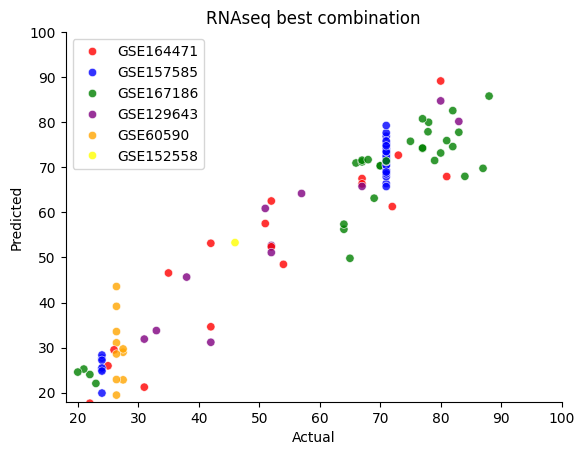

In [7]:
results = result_df_rnaseq
custom_palette = {
        'GSE164471': 'red',
        'GSE157585': 'blue',
        'GSE167186': 'green',
        'GSE129643': 'purple',
        'GSE60590': 'orange',
        'GSE152558': 'yellow'
    }

label_order = ['GSE164471', 'GSE157585', 'GSE167186', 'GSE129643', 'GSE60590', 'GSE152558']

sns.scatterplot(x='Actual', y='Predicted', hue='Group', data=results, palette=custom_palette, hue_order=label_order, alpha=0.8, edgecolor='w')

#plt.scatter(y_test, ridge.predict(X_test), hue=z, label='Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('RNAseq best combination')
plt.xlim(18, 100)
plt.ylim(18, 100)
plt.legend()


# Get the current axes object
ax = plt.gca()

# Remove the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Show the plot

plt.show()

In [35]:
eval, result_df = eval_regression_file("micro_2_Combat.csv", method="L2")

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


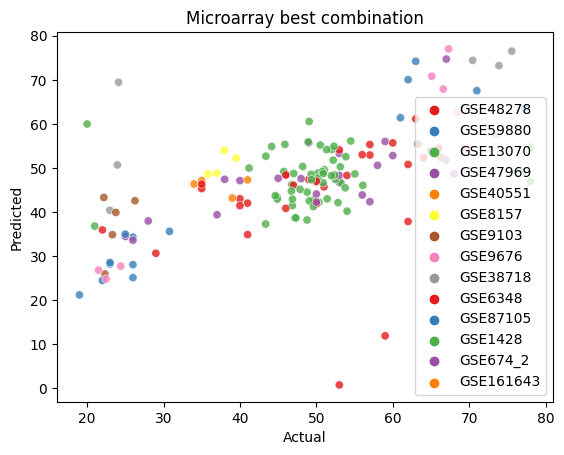

In [37]:
results = result_df
sns.scatterplot(x='Actual', y='Predicted', hue='Group', data=results, palette='Set1', alpha=0.8, edgecolor='w')

#plt.scatter(y_test, ridge.predict(X_test), hue=z, label='Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Microarray best combination')
plt.legend()
plt.show()

In [ ]:
eval_all = []

for f in files:
    eval={"File": f}
    if "micro" in f:
        eval["Technology"]="Microarray"
    else:
        eval["Technology"]= "RNAseq"
    
    if "z" in f:
        eval["Normalization"]= "Z-score"
    else:
        eval["Normalization"]="Two-step"
    
    if "reCombat" in f:
        eval["BatchCorrection"]= "reCombat"
    else:
        eval["BatchCorrection"]="Combat"
        
    dataset = pd.read_csv(f"{root}/{f}")
    section_df = dataset.drop(columns=["Age"])
    section_df_age = dataset["Age"]
    section_df = m.remove_non_numeric_columns(section_df)
    result_df, result_metrics = reg.ridge_L2(X=section_df, y=section_df_age, z=dataset["Experiment"])
    age_ranges = divide.get_age_distribution(result_df["Actual"], age_ranges=[18, 25, 35, 45,50,55,60,70, 100])
    y_train_cat = result_df["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
    y_test_cat = result_df["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))

    cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})
    mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])
    result_metrics["MCC"]= mcc
    eval.update(result_metrics)

    eval_all.append(eval)
    print(eval)

eval_all
    

In [ ]:
for f in files:
    eval={"File": f}
    if "micro" in f:
        eval["Technology"]="Microarray"
    else:
        eval["Technology"]= "RNAseq" 
    
    if "z" in f:
        eval["Normalization"]= "Z-score"
    else:
        eval["Normalization"]="Two-step"
    
    if "reCombat" in f:
        eval["BatchCorrection"]= "reCombat"
    else:
        eval["BatchCorrection"]="Combat"
        
    dataset = pd.read_csv(f"{root}/{f}")
    section_df = dataset.drop(columns=["Age"])
    section_df_age = dataset["Age"]
    section_df = m.remove_non_numeric_columns(section_df)
    result_df, result_metrics = reg.lasso_L1(X=section_df, y=section_df_age, z=dataset["Experiment"])
    age_ranges = divide.get_age_distribution(result_df["Actual"], age_ranges=[18, 25, 35, 45,50,55,60,70, 100])
    y_train_cat = result_df["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
    y_test_cat = result_df["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))

    cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})
    mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])
    result_metrics["MCC"]= mcc
    eval.update(result_metrics)

    eval_all.append(eval)
    #print(eval)

eval_all

In [16]:
eval_df = pd.DataFrame(eval_all)
eval_df

,File,Technology,Normalization,BatchCorrection,Method,MSE,RMSE,MAE,R2,MCC
0,micro_z_Combat.csv,Microarray,Z-score,Combat,Ridge Regression,148.579725,12.189328,8.027510,0.277900,0.216502
1,RNAs_2_reCombat.csv,RNAseq,Two-step,reCombat,Ridge Regression,1928.447425,43.914091,32.899328,-2.752433,0.095418
2,micro_2_Combat.csv,Microarray,Two-step,Combat,Ridge Regression,139.193311,11.798021,8.193385,0.323518,0.188268
3,micro_z_reCombat.csv,Microarray,Z-score,reCombat,Ridge Regression,388.706060,19.715630,12.237721,-0.889119,0.172838
4,RNAs_z_Combat.csv,RNAseq,Z-score,Combat,Ridge Regression,172.243350,13.124151,10.300058,0.664843,0.239949
5,micro_2_reCombat.csv,Microarray,Two-step,reCombat,Ridge Regression,369.532563,19.223230,12.877579,-0.795935,0.058076
6,RNAs_2_Combat.csv,RNAseq,Two-step,Combat,Ridge Regression,210.574439,14.511183,10.896705,0.590258,0.303764
7,RNAs_z_reCombat.csv,RNAseq,Z-score,reCombat,Ridge Regression,1928.447425,43.914091,32.899328,-2.752433,0.095418
8,micro_z_Combat.csv,Microarray,Z-score,Combat,LASSO Regression,205.075424,14.320455,10.967807,0.003330,0.058853
9,RNAs_2_reCombat.csv,RNAseq,Two-step,reCombat,LASSO Regression,569.700044,23.868390,18.863236,-0.108540,-0.024067


In [17]:
eval_df.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/regression_all_LASSO_RIDGE.csv", index=False)

In [13]:
#eval_df = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/regression_all_LASSO_RIDGE.csv")

In [18]:
microarray_df = eval_df[eval_df["Technology"]=="Microarray"]
microarray_df = microarray_df.select_dtypes(include=np.number)
microarray_average = microarray_df.mean()
microarray_average

MSE     217.193499
RMSE     14.464401
MAE      10.314795
R2       -0.055565
MCC       0.108633
dtype: float64

In [20]:
eval={"File": f}
if "micro" in f:
    eval["Technology"]="Microarray"
else:
    eval["Technology"]= "RNAseq"

if "z" in f:
    eval["Normalization"]= "Z-score"
else:
    eval["Normalization"]="Two-step"

if "reCombat" in f:
    eval["BatchCorrection"]= "reCombat"
else:
    eval["BatchCorrection"]="Combat"
    
dataset = pd.read_csv(f"{root}/{f}")
section_df = dataset.drop(columns=["Age"])
section_df_age = dataset["Age"]
section_df = m.remove_non_numeric_columns(section_df)
result_df, result_metrics = reg.lasso_L1(X=section_df, y=section_df_age, z=dataset["Experiment"])
age_ranges = divide.get_age_distribution(result_df["Actual"], age_ranges=[18, 25, 35, 45,50,55,60,70, 100])
y_train_cat = result_df["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
y_test_cat = result_df["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))

cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})
mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])
result_metrics["MCC"]= mcc
eval.update(result_metrics)

eval
#print(eval)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'File': 'RNAs_z_reCombat.csv',
 'Technology': 'RNAseq',
 'Normalization': 'Z-score',
 'BatchCorrection': 'reCombat',
 'Method': 'LASSO Regression',
 'MSE': 401.44162142323427,
 'RMSE': 20.036008120961476,
 'MAE': 16.188300208185538,
 'R2': 0.21886230719468736,
 'MCC': 0.0810428786666849}

In [21]:
f

'RNAs_z_reCombat.csv'

In [14]:
age_ranges = divide.get_age_distribution(result_df["Actual"], age_ranges=[18, 25, 35, 45,50,55,60,70, 100])
age_ranges
age_ranges = divide.get_age_distribution(result_df["Actual"], age_ranges=[18, 25, 35, 45,50,60,70, 100])
age_ranges

[{'label': '18-25', 'range': (18, 25), 'count': 10},
 {'label': '25-35', 'range': (25, 35), 'count': 10},
 {'label': '35-45', 'range': (35, 45), 'count': 3},
 {'label': '45-50', 'range': (45, 50), 'count': 1},
 {'label': '50-60', 'range': (50, 60), 'count': 3},
 {'label': '60-70', 'range': (60, 70), 'count': 4},
 {'label': '70-100', 'range': (70, 100), 'count': 23}]

In [20]:
y_train_cat = result_df["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
y_test_cat = result_df["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))


cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})
mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])



TypeError: 'numpy.ndarray' object is not callable

In [21]:
cat_results=cat_results[cat_results["Predicted"]!="Unknown"]

In [28]:
confusion_matrix_table = confusion_matrix(cat_results["Actual"], cat_results["Predicted"])
confusion_matrix_table

array([[1, 4, 3, 1, 0, 0, 0],
       [4, 3, 2, 0, 1, 0, 0],
       [1, 0, 2, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 2, 0, 0],
       [0, 0, 0, 0, 1, 3, 0],
       [0, 0, 1, 0, 7, 7, 8]])

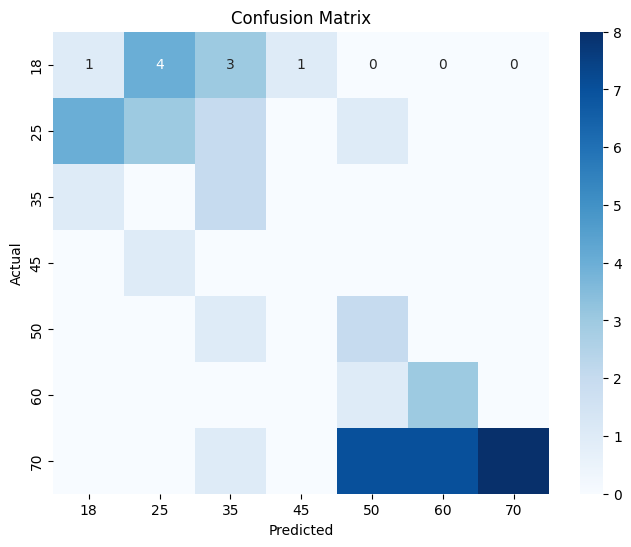

In [32]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_table, cmap='Blues', 
 xticklabels=[18, 25, 35, 45,50,60,70], yticklabels=[18, 25, 35, 45,50,60,70], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:

def ridge_L2_mod(X,y,z=None, alpha=1.0):

    X_train, X_test, y_train, y_test, z_train, z_test = train_test_split(X, y,z, test_size=0.4, random_state=42)
    # Initialize Ridge regression model
    ridge = Ridge(alpha=alpha)  # You can adjust the alpha parameter as needed

    # Train the model
    ridge.fit(X_train, y_train)    
    y_pred = ridge.predict(X_test)

    

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)  # Calculate RMSE from MSE
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    

    result_metrics = {"Method": "Ridge Regression",  "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}


    results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Group': z_test})
    return results, result_metrics


reg.ridge_L2=ridge_L2_mod



eval, result_df_rnaseq = eval_regression_file("RNAs_z_Combat.csv", method="L2")
eval

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'File': 'RNAs_z_Combat.csv',
 'Technology': 'RNAseq',
 'Normalization': 'Z-score',
 'BatchCorrection': 'Combat',
 'Method': 'Ridge Regression',
 'MSE': 529.6839633199272,
 'RMSE': 23.014863964836447,
 'MAE': 14.168059790541783,
 'R2': -0.15121005117112696,
 'MCC': 0.16764185178526766}

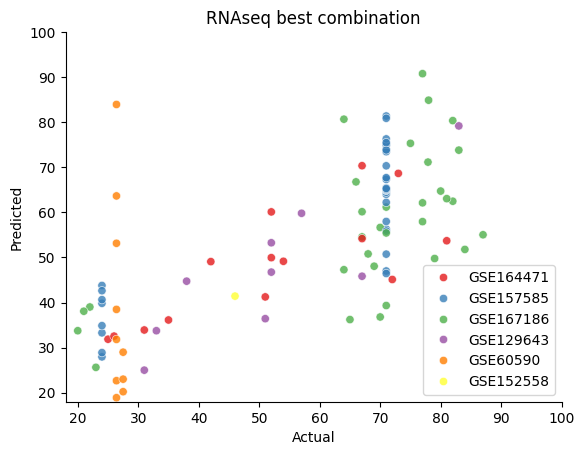

In [14]:
results = result_df_rnaseq
sns.scatterplot(x='Actual', y='Predicted', hue='Group', data=results, palette='Set1', alpha=0.8, edgecolor='w')

#plt.scatter(y_test, ridge.predict(X_test), hue=z, label='Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('RNAseq best combination')
plt.xlim(18, 100)
plt.ylim(18, 100)
plt.legend()
ax = plt.gca()

# Remove the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Show the plot
plt.show()